## E1 - optimizer comparison

Baseline (Adam) already trained and saved, not rerun here. This notebook trains SGD+momentum, SGD+Nesterov, Adagrad, and RMSprop from the same init and lines them up against the baseline history. Val accuracy is already near ceiling from the baseline run, so the comparison here is mostly about convergence speed and val_loss, not final accuracy.

In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import pandas as pd
import matplotlib.pyplot as plt

from citrus_model import CitrusNet, init_weights
from citrus_common import load_normalization_stats, get_transforms, CitrusLeafDataset
from citrus_train import set_seed, fit

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


### Data

Same loaders as the baseline notebook - 224px, batch 32, num_workers=0 (Windows).

In [2]:
set_seed(42)

mean, std = load_normalization_stats()

train_transform = get_transforms(augment=True, mean=mean, std=std, size=224)
val_transform = get_transforms(augment=False, mean=mean, std=std, size=224)

train_dataset = CitrusLeafDataset(root_dir="processed/224", split="train", transform=train_transform)
val_dataset = CitrusLeafDataset(root_dir="processed/224", split="val", transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)

len(train_dataset), len(val_dataset)

(1131, 242)

### Loss and optimizer configs

Same class weights and weight_decay as baseline. Adam's config is listed here for reference but it's not retrained - its history gets read back in from CSV further down.

In [3]:
class_weights = torch.tensor([0.9921, 0.9240, 1.1880, 0.9363], dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

WEIGHT_DECAY = 1e-4

optimizer_configs = {
    "sgd_momentum": lambda params: optim.SGD(params, lr=0.01, momentum=0.9, weight_decay=WEIGHT_DECAY),
    "sgd_nesterov": lambda params: optim.SGD(params, lr=0.01, momentum=0.9, nesterov=True, weight_decay=WEIGHT_DECAY),
    "adagrad": lambda params: optim.Adagrad(params, lr=0.01, weight_decay=WEIGHT_DECAY),
    "rmsprop": lambda params: optim.RMSprop(params, lr=1e-3, weight_decay=WEIGHT_DECAY),
}

### Training runs

Fresh CitrusNet + init_weights before each run, seed reset right before each model is built so all four start from the same weights.

In [4]:
os.makedirs("checkpoints", exist_ok=True)

histories = {}

for name, make_optimizer in optimizer_configs.items():
    print(f"--- training: {name} ---")

    set_seed(42)
    model = CitrusNet(num_classes=4)
    init_weights(model)
    model = model.to(device)

    optimizer = make_optimizer(model.parameters())
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)

    history = fit(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        max_epochs=100,
        early_stop_patience=10,
        scheduler=scheduler,
        checkpoint_path=f"checkpoints/opt_{name}_best.pt",
        verbose=True,
    )

    hist_df = pd.DataFrame(history)
    hist_df.to_csv(f"history_opt_{name}.csv", index=False)
    histories[name] = hist_df

--- training: sgd_momentum ---
epoch   1  train_loss 1.0575  train_acc 0.5287  val_loss 1.0454  val_acc 0.5620  lr 1.00e-02
epoch   2  train_loss 0.5754  train_acc 0.7639  val_loss 0.3245  val_acc 0.8678  lr 1.00e-02
epoch   3  train_loss 0.4297  train_acc 0.8523  val_loss 0.3105  val_acc 0.9008  lr 1.00e-02
epoch   4  train_loss 0.3423  train_acc 0.8957  val_loss 0.1748  val_acc 0.9463  lr 1.00e-02
epoch   5  train_loss 0.3058  train_acc 0.8904  val_loss 0.3963  val_acc 0.8223  lr 1.00e-02
epoch   6  train_loss 0.2584  train_acc 0.9151  val_loss 0.0864  val_acc 0.9669  lr 1.00e-02
epoch   7  train_loss 0.3143  train_acc 0.8842  val_loss 0.1097  val_acc 0.9587  lr 1.00e-02
epoch   8  train_loss 0.2053  train_acc 0.9372  val_loss 0.0592  val_acc 0.9917  lr 1.00e-02
epoch   9  train_loss 0.1870  train_acc 0.9408  val_loss 0.0802  val_acc 0.9669  lr 1.00e-02
epoch  10  train_loss 0.1713  train_acc 0.9496  val_loss 0.0926  val_acc 0.9835  lr 1.00e-02
epoch  11  train_loss 0.1889  train_acc

### Bring in the Adam baseline

In [5]:
histories_ordered = {"adam": pd.read_csv("history_baseline.csv")}
histories_ordered.update(histories)

In [7]:
def ensure_epoch_column(df):
    df = df.reset_index(drop=True)
    if "epoch" not in df.columns:
        df.insert(0, "epoch", range(1, len(df) + 1))
    return df

# works whether histories_ordered is still in memory or you restarted the kernel
try:
    histories_ordered
except NameError:
    histories_ordered = {"adam": pd.read_csv("history_baseline.csv")}
    for name in ["sgd_momentum", "sgd_nesterov", "adagrad", "rmsprop"]:
        histories_ordered[name] = pd.read_csv(f"history_opt_{name}.csv")

histories_ordered = {name: ensure_epoch_column(df) for name, df in histories_ordered.items()}

### Summary table

`epochs_to_reach_99pct` is the first epoch where val_acc >= 0.99, or "never" if it doesn't get there. Sorted fastest first.

In [8]:
def summarize(name, df):
    best_idx = df["val_loss"].idxmin()
    reached = df[df["val_acc"] >= 0.99]
    epochs_to_99 = int(reached["epoch"].iloc[0]) if len(reached) > 0 else "never"

    return {
        "optimizer": name,
        "epochs_run": int(df["epoch"].max()),
        "best_epoch": int(df.loc[best_idx, "epoch"]),
        "best_val_loss": float(df.loc[best_idx, "val_loss"]),
        "best_val_acc": float(df.loc[best_idx, "val_acc"]),
        "epochs_to_reach_99pct": epochs_to_99,
    }

summary_df = pd.DataFrame([summarize(name, df) for name, df in histories_ordered.items()])

sort_key = summary_df["epochs_to_reach_99pct"].apply(lambda v: float("inf") if v == "never" else v)
summary_df = summary_df.iloc[sort_key.argsort()].reset_index(drop=True)

summary_df

,optimizer,epochs_run,best_epoch,best_val_loss,best_val_acc,epochs_to_reach_99pct
0,adam,40,30,0.001026,1.0,4
1,sgd_momentum,47,37,0.004361,1.0,8
2,sgd_nesterov,62,52,0.002423,1.0,8
3,rmsprop,51,41,0.000507,1.0,10
4,adagrad,51,41,0.001967,1.0,11


### Val loss, log scale

Log scale because most of these will be sitting close to zero by the end and a linear axis just flattens everything.

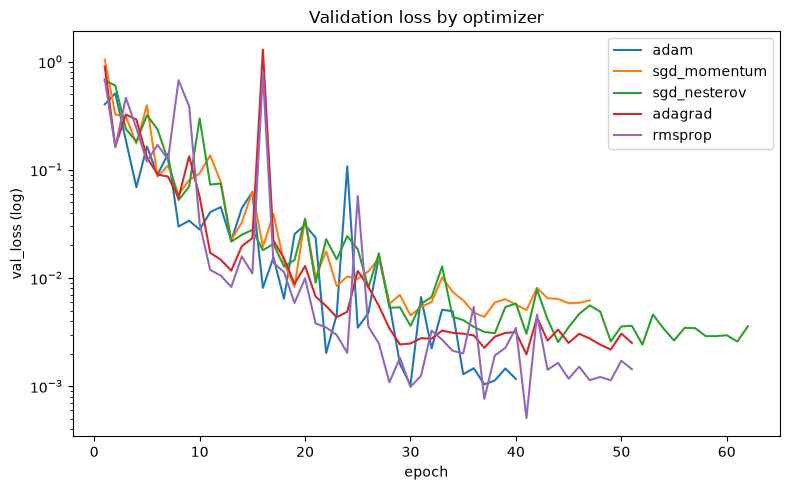

In [9]:
plt.figure(figsize=(8, 5))
for name, df in histories_ordered.items():
    plt.plot(df["epoch"], df["val_loss"], label=name)

plt.yscale("log")
plt.xlabel("epoch")
plt.ylabel("val_loss (log)")
plt.title("Validation loss by optimizer")
plt.legend()
plt.tight_layout()
plt.show()

### Val accuracy, early-training view

Unclipped from 0.5 so the early-epoch gap between optimizers is visible, even though most converge close to 1.0 eventually.

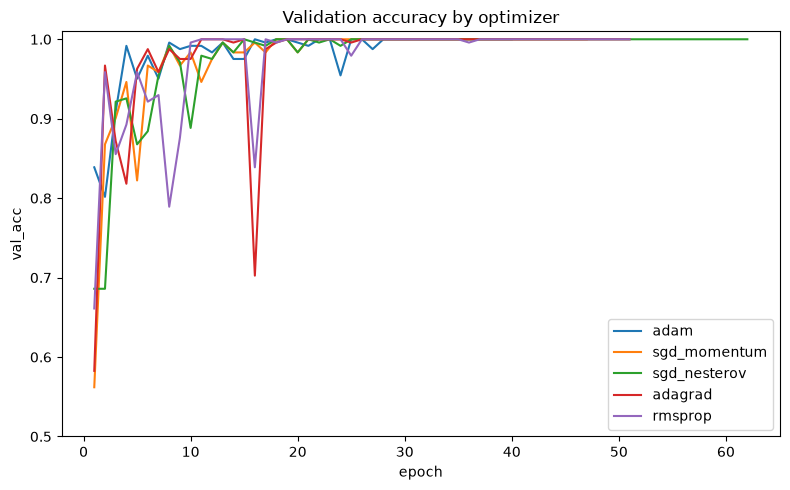

In [10]:
plt.figure(figsize=(8, 5))
for name, df in histories_ordered.items():
    plt.plot(df["epoch"], df["val_acc"], label=name)

plt.ylim(0.5, 1.01)
plt.xlabel("epoch")
plt.ylabel("val_acc")
plt.title("Validation accuracy by optimizer")
plt.legend()
plt.tight_layout()
plt.show()

### Summary

In [11]:
fastest_row = summary_df.iloc[0]
lowest_loss_row = summary_df.loc[summary_df["best_val_loss"].idxmin()]
never_reached = summary_df.loc[summary_df["epochs_to_reach_99pct"] == "never", "optimizer"].tolist()

print(f"fastest to 99% val acc: {fastest_row['optimizer']} (epoch {fastest_row['epochs_to_reach_99pct']})")
print(f"lowest best val loss: {lowest_loss_row['optimizer']} ({lowest_loss_row['best_val_loss']:.6f})")

if never_reached:
    print(f"never reached 99% val acc: {', '.join(never_reached)}")
else:
    print("all optimizers reached 99% val acc within their run")

fastest to 99% val acc: adam (epoch 4)
lowest best val loss: rmsprop (0.000507)
all optimizers reached 99% val acc within their run
